# Кескіндердің шеттерін, бұрыштарын және дақтарын анықтау


## Ноутбук мазмұны

| Бөлім | Тақырып |
|---|---|
| 3.1 | Бірінші туындыға негізделген операторлар (Sobel, Prewitt) |
| 3.2 | Екінші туынды және Canny алгоритмі |
| 4.1 | Бұрыштарды анықтау: Harris, NCC |
| 4.2 | Жылдам дескрипторлар: FAST, ORB |
| 4.3 | Дақтарды анықтау: SimpleBlobDetector |
| — | Тапсырмалар |


## Жалпы мақсат

Бұл ноутбукта компьютерлік көрудің іргелі тапсырмалары  **шеттерді анықтау** (Edge Detection), **бұрыштарды анықтау** (Corner Detection) және **дақтарды анықтау** (Blob Detection)  кезең-кезеңімен зерттеледі.

Аталған операциялар объектілерді сегментациялау, кескіндерді тіркеу (image registration), панорамаларды біріктіру және 3D реконструкциялау алгоритмдерінің негізін құрайды.

**Негізгі ұғымдар:**

- **Шет (Edge)** — кескіндегі жарықтықтың немесе түстің күрт өзгеретін аймағы.
- **Бұрыш (Corner)** — барлық бағытта жарықтығы күрт өзгеретін нүкте; тұрақты локальді ерекшелік.
- **Дақ (Blob)** — фоннан жарықтығы немесе түсі бойынша ерекшеленетін біртекті тұйық аймақ.


# 3. Кескіндердің шеттерін анықтау (Edge Detection)

Бұл бөлімде кескіндегі объектілердің шекараларын табу әдістері зерттеледі. Шеттерді анықтау объектілерді сегментациялау және олардың пішінін талдау үшін өте маңызды.



## 3.1 Бірінші туындыға негізделген операторлар

**Мақсаты:** Собель (Sobel) операторын қолдану арқылы кескін градиенттерін есептеу және объектілердің көлденең, тік шеттерін табу.

Шеттерді анықтау кескіндегі жарықтықтың күрт өзгеретін аймақтарын табу процесі. Бірінші туындыға негізделген операторлар (мысалы, Собель немесе Превитт) осы жарықтық өзгерістерінің бағыты мен күшін (градиентін) есептейді. Бұл әдіс математикалық матрицаларды (ядроларды) пайдаланып, көлденең және тік шеттерді бөлек табуға мүмкіндік береді.

### Теориялық негіз

Сандық кескін үшін бірінші туынды конволюция ядролары арқылы жуықталады.

**Sobel ядролары:**

```
Gx (тік шеттер):          Gy (көлденең шеттер):
┌  -1   0  +1 ┐           ┌  -1  -2  -1 ┐
│  -2   0  +2 │           │   0   0   0 │
└  -1   0  +1 ┘           └  +1  +2  +1 ┘
```

Жалпы градиент магнитудасы:

```
G = sqrt(Gx^2 + Gy^2)
```

Градиент бағыты:

```
theta = arctan(Gy / Gx)
```

### Sobel операторының балама нұсқалары

| Оператор | Функция | Ерекшелігі |
|---|---|---|
| Sobel | `cv2.Sobel(gray, cv2.CV_64F, dx, dy, ksize)` | Жиі қолданылады, шуға орташа төзімді |
| Prewitt | Қолмен ядро + `cv2.filter2D()` | Sobel-ге ұқсас, салмақсыз |
| Scharr | `cv2.Scharr(gray, cv2.CV_64F, dx, dy)` | Айналуға дәлірек, `ksize=-1` баламасы |
| Roberts | 2x2 ядро + `filter2D` | Жылдам, шуға сезімтал |

**Prewitt операторын cv2 арқылы қолдану мысалы:**

```python
kernel_x = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]], dtype=np.float64)
prewitt_x = cv2.filter2D(gray, cv2.CV_64F, kernel_x)
```

**Scharr операторын cv2 арқылы қолдану:**

```python
scharr_x = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(gray, cv2.CV_64F, 0, 1)
```

### cv2.Sobel параметрлері

| Параметр | Сипаттамасы |
|---|---|
| `src` | Кіріс кескін (сұр реңкті) |
| `ddepth` | Шығыс тереңдігі; `cv2.CV_64F` теріс мәндерді сақтайды |
| `dx` | X бойынша туынды дәрежесі (0 немесе 1) |
| `dy` | Y бойынша туынды дәрежесі (0 немесе 1) |
| `ksize` | Ядро өлшемі: 1, 3, 5 немесе 7 |


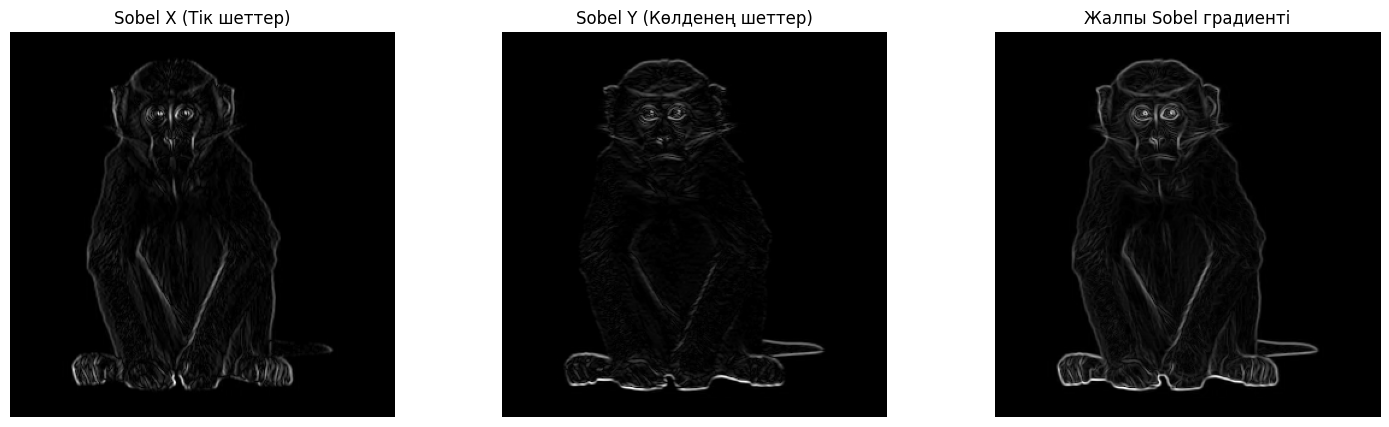

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Кескінді оқу және сұр түске айналдыру
image = cv2.imread('/content/i (5) (1).webp')
# BGR → RGB (matplotlib үшін)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Gray формат
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# X осі бойынша Собель операторы (тік шеттер)
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

# Y осі бойынша Собель операторы (көлденең шеттер)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Жалпы градиентті есептеу (екі бағытты біріктіру)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Нәтижелерді визуализациялау
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(np.abs(sobel_x), cmap='gray')
ax[0].set_title('Sobel X (Тік шеттер)')
ax[1].imshow(np.abs(sobel_y), cmap='gray')
ax[1].set_title('Sobel Y (Көлденең шеттер)')
ax[2].imshow(sobel_combined, cmap='gray')
ax[2].set_title('Жалпы Sobel градиенті')
for a in ax: a.axis('off')
plt.show()

**Нәтижені түсіндіру:**

- `Sobel X` — тік шеттерді (жарықтық солдан оңға қарай өзгеретін жерлер) айқын көрсетеді.
- `Sobel Y` — көлденең шеттерді (жарықтық жоғарыдан төменге қарай өзгеретін жерлер) айқын көрсетеді.
- `Жалпы градиент` — екі бағыттағы шеттердің жиынтығы; объект шекаралары толық суреттеледі.

> Ескерту: `cv2.CV_64F` типі теріс градиент мәндерін сақтауға мүмкіндік береді. `np.abs()` арқылы олар визуализация үшін оң мәнге айналдырылады. `cv2.convertScaleAbs()` функциясы — жиі қолданылатын балама тәсіл.



## 3.2 Екінші туындыға негізделген операторлар және Канни алгоритмі

**Мақсаты:** Лапласиан (Laplacian) операторын және заманауи Канни (Canny) шет анықтау алгоритмін тәжірибеде қолдану және салыстыру.

Екінші туынды (мысалы, Laplacian) нөлге тең болатын нүктелерді табу арқылы шеттерді дәлірек анықтауға көмектеседі, бірақ ол шуға өте сезімтал. Сондықтан іс жүзінде Канни (Canny) алгоритмі жиі қолданылады. Ол шуды басу (Гаусс фильтрі), градиенттерді есептеу, шеттерді жіңішкерту (максималды емес мәндерді басу) және қос табалдырықты (double threshold) қолдану сияқты көп сатылы, өте сенімді кешенді әдіс болып табылады.

### Теориялық негіз

**Laplacian ядросы (3x3):**

```
┌   0  -1   0 ┐
│  -1  +4  -1 │
└   0  -1   0 ┘
```

Laplacian кескіннің екінші туындысын есептейді:

```
Delta f = d^2f/dx^2 + d^2f/dy^2
```

### Canny алгоритмінің кезеңдері

Canny алгоритмі 1986 жылы Джон Канни ұсынған, бүгінгі күнге дейін ең тиімді шет анықтау тәсілі болып саналады:

```
1-кезен: Шуды кетіру    — Gaussian blur арқылы кескінді тегістеу
2-кезен: Градиент       — Sobel операторы арқылы Gx, Gy есептеу
3-кезен: NMS            — Non-maximum suppression (шеттерді 1 пиксельге жіңішкерту)
4-кезен: Гистерезис     — threshold1 < шет < threshold2 шарты бойынша сүзгілеу
```

### Табалдырықтарды таңдау нұсқаулығы

| Жағдай | threshold1 | threshold2 | Нәтиже |
|---|---|---|---|
| Аз детальдар | 50 | 150 | Тек айқын шеттер |
| Орташа | 100 | 200 | Теңгерімді нәтиже |
| Көп детальдар | 30 | 80 | Ұсақ шеттер де анықталады |

> Ұсыным: `threshold2 / threshold1 = 2:1` немесе `3:1` қатынасы жақсы нәтиже береді.

### Шет анықтау алгоритмдерін жалпы салыстыру

| Алгоритм | Шуға төзімділік | Жылдамдық | Шет жіңішкелігі | Қолданылуы |
|---|---|---|---|---|
| Sobel | Орташа | Жоғары | Жуан | Жылдам алғашқы өңдеу |
| Prewitt | Орташа | Жоғары | Жуан | Жеңіл есептер |
| Laplacian | Төмен | Жоғары | Жіңішке | Теориялық талдау |
| Canny | Жоғары | Орташа | Жіңішке (1px) | Іс жүзіндегі қолдану |


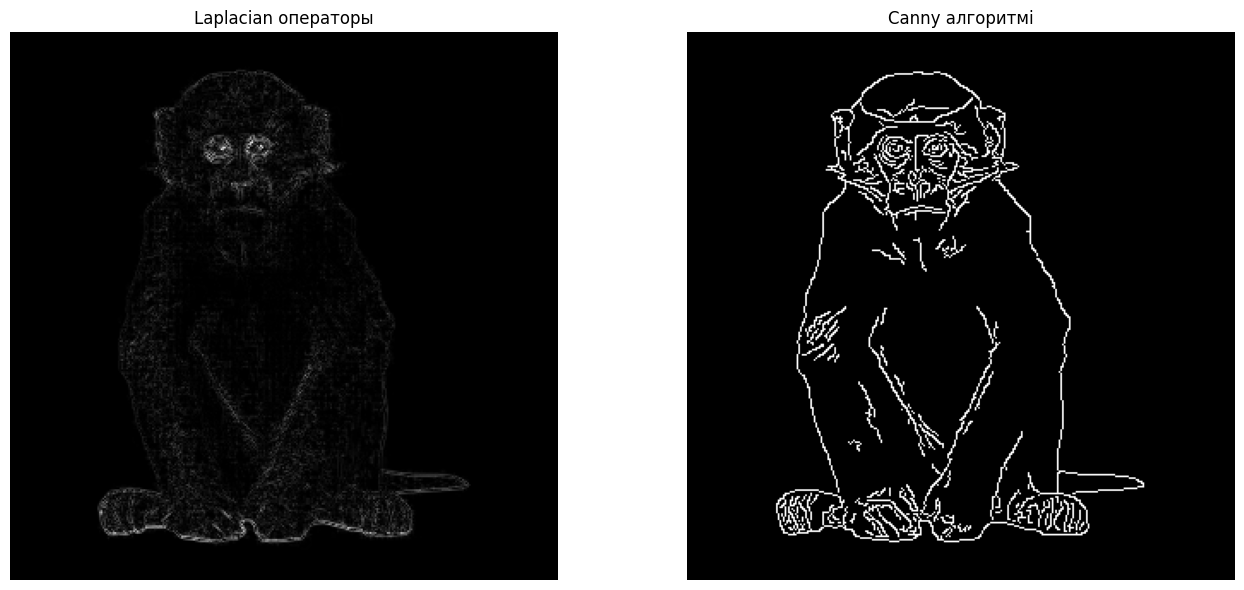

In [ ]:
# Лапласиан операторын қолдану
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Канни алгоритмін қолдану (төменгі және жоғарғы табалдырықтар: 100 және 200)
canny_edges = cv2.Canny(gray, 100, 200)

# Нәтижелерді көрсету
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(np.abs(laplacian), cmap='gray')
ax[0].set_title('Laplacian операторы')
ax[0].axis('off')

ax[1].imshow(canny_edges, cmap='gray')
ax[1].set_title('Canny алгоритмі')
ax[1].axis('off')

plt.tight_layout()
plt.show()

**Нәтижені түсіндіру:**

- `Laplacian` — шеттерді бір мезетте барлық бағытта анықтайды, бірақ шуды да күшейтеді.
- `Canny` — шу кетірілгеннен кейін тек нақты, жіңішке шеттер қалады; іс жүзінде ең сенімді нәтиже.

**LoG (Laplacian of Gaussian) — Laplacian-ға жақсартылған балама:**

```python
# Алдымен шуды кетіру, сосын Laplacian қолдану
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
log = cv2.Laplacian(blurred, cv2.CV_64F)
```


# 4. Бұрыштар мен дақтарды анықтау және сипаттау

Бұл бөлімде кескіндегі локальді ерекшеліктерді (features) табу құралдары зерттеледі. Бұл әдістер объектілерді тану, панорамаларды біріктіру және 3D реконструкциялау үшін негіз болады.


## 4.1 Бұрыштарды анықтау және сипаттау. Харрис және NCC

**Мақсаты:** Харрис (Harris Corner Detector) алгоритмі арқылы кескіндегі бұрыштарды табу және олардың негізгі қасиеттерін түсіну.

Бұрыштар барлық бағытта жарықтығы күрт өзгеретін, кескіннің ең тұрақты ерекшеліктерінің бірі. Харрис алгоритмі кішігірім терезе ішіндегі пиксельдердің әртүрлі бағыттағы ығысуын талдау арқылы осындай бұрыштарды тиімді табады. Табылған бұрыштарды өзге суреттермен салыстыру үшін NCC (Normalized Cross-Correlation) сияқты кросс-корреляциялық метрикалар қолданылуы мүмкін.

### Теориялық негіз

Харрис алгоритмі **Структуралық тензор (M матрица)** арқылы жұмыс істейді:

```
M = | Ix^2    Ix*Iy |
    | Ix*Iy   Iy^2  |

R = det(M) - k * trace(M)^2

мұнда:
  det(M) = lambda1 * lambda2
  trace(M) = lambda1 + lambda2
  k — Харрис коэффициенті (0.04 — 0.06 арасында)
```

**Шешім қабылдау:**

```
R >> 0   — бұрыш (corner)
R << 0   — шет (edge)
R ~ 0    — жалпақ аймақ (flat region)
```

### Бұрыш анықтаушылардың салыстырмасы

| Алгоритм | Функция | Айналуға төзімді | Масштабқа төзімді | Жылдамдық |
|---|---|---|---|---|
| Harris | `cv2.cornerHarris()` | Иә | Жоқ | Жылдам |
| Shi-Tomasi | `cv2.goodFeaturesToTrack()` | Иә | Жоқ | Жылдам |
| SIFT | `cv2.SIFT_create()` | Иә | Иә | Баяу |
| FAST | `cv2.FastFeatureDetector_create()` | Ішінара | Жоқ | Өте жылдам |
| ORB | `cv2.ORB_create()` | Иә | Ішінара | Жылдам |

**Shi-Tomasi — Харристің жақсартылған нұсқасы:**

```python
# maxCorners: ең көп нүкте саны, qualityLevel: минималды сапа, minDistance: нүктелер арақашықтығы
corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
```

**NCC (Normalized Cross-Correlation) — үлгімен салыстыру:**

```python
# template — іздейтін үлгі кескін
result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
```

### cv2.cornerHarris параметрлері

| Параметр | Сипаттамасы | Ұсынылған мән |
|---|---|---|
| `blockSize` | Көршілес пиксельдер аймағының өлшемі | 2 — 5 |
| `ksize` | Sobel ядросының өлшемі | 3 немесе 5 |
| `k` | Харрис еркін коэффициенті | 0.04 — 0.06 |


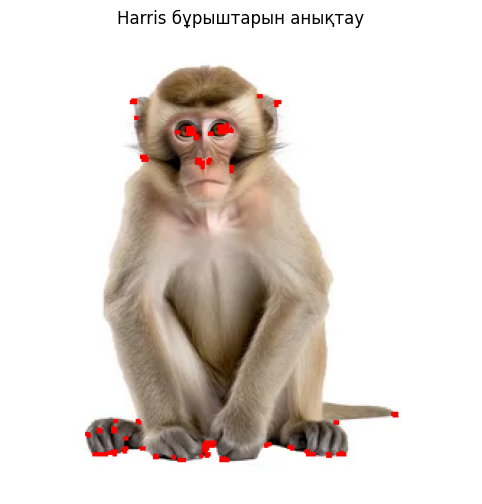

In [ ]:
# Харрис алгоритмі үшін float32 форматы қажет
gray_float = np.float32(gray)

# Харрис бұрыштарын анықтау (блок өлшемі 2, Собель ядросы 3, Харрис параметрі 0.04)
dst = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Нәтижені жақсарту үшін дилатация (кеңейту) жасау
dst = cv2.dilate(dst, None)

# Түпнұсқа кескіннің көшірмесін жасау
image_harris = image_rgb.copy()

# Ең жақсы бұрыштарды қызыл түспен белгілеу (максималды мәннің 1%-нан жоғарылары)
image_harris[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.figure(figsize=(8, 6))
plt.imshow(image_harris)
plt.title('Harris бұрыштарын анықтау')
plt.axis('off')
plt.show()

**Нәтижені түсіндіру:**

Қызыл нүктелермен белгіленген пиксельдер Harris алгоритмі бұрыш ретінде анықтаған аймақтар. Объект шеттерінің қиылысу нүктелері, текстура өзгерістері және сайып келгенде ең тұрақты локальді ерекшеліктер осылайша көрінеді.

Табалдырық мәні (`0.01 * dst.max()`) анықталатын бұрыштар санын реттейді: мән азайса — бұрыштар көбейеді, мән артса — тек ең айқын бұрыштар қалады.


## 4.2 Бұрыштарды анықтау және сипаттау. FAST және ORB

**Мақсаты:** Нақты уақытта жұмыс істеуге бейімделген FAST және ORB алгоритмдерін пайдаланып ерекше нүктелерді табу.

FAST (Features from Accelerated Segment Test) алгоритмі орталық пиксельді оның айналасындағы шеңбердегі пиксельдермен салыстыру арқылы бұрыштарды өте жылдам табады. Ал ORB (Oriented FAST and Rotated BRIEF) — FAST алгоритмін бұрыштарды табу үшін және BRIEF алгоритмін оларды сипаттау (дескриптор) үшін біріктіретін, масштаб пен айналуға төзімді, әрі патенттелмеген тегін балама.

### Теориялық негіз

**FAST алгоритмінің принципі:**

```
Орталық пиксель p (жарықтық: Ip)
Радиусы 3 шеңбердегі 16 пиксель тексеріледі.

Шарт: егер N немесе одан да көп пиксель
  Ip + threshold немесе Ip - threshold-тан ауытқыса —> БҰРЫШ.
```

**ORB = FAST + BRIEF + бағдар есебі:**

```
1. FAST арқылы нүктелерді табу
2. Harris баллын есептеп ең жақсыларды сүзу
3. Масштаб пирамидасы (Image Pyramid) арқылы масштабқа төзімділік
4. Бас бағытты (orientation) есептеу — айналуға төзімділік
5. rBRIEF — бинарлы дескриптор генерациясы
```

### Жиі қолданылатын ерекше нүкте дескрипторлары

| Дескриптор | Тип | Өлшем | Лицензия | Ерекшелігі |
|---|---|---|---|---|
| SIFT | Жылжымалы нүкте | 128 float | Ашық (OpenCV 4.4+) | Масштаб + айналуға төзімді |
| SURF | Жылжымалы нүкте | 64 float | Патент | SIFT-тен жылдам |
| ORB | Бинарлы | 256 бит | Ашық | Жылдам, тегін |
| BRIEF | Бинарлы | 256 бит | Ашық | Тек дескриптор, детектор емес |
| AKAZE | Бинарлы | 486 бит | Ашық | Бейсызықтық масштаб кеңістігі |

### cv2.ORB_create() параметрлері

| Параметр | Мәні бойынша | Сипаттамасы |
|---|---|---|
| `nfeatures` | 500 | Максималды нүкте саны |
| `scaleFactor` | 1.2 | Пирамида масштаб коэффициенті |
| `nlevels` | 8 | Пирамида деңгейлері саны |
| `edgeThreshold` | 31 | Шет аймақтарын ескермеу аралығы |
| `patchSize` | 31 | BRIEF үшін үлгі өлшемі |

**Екі кескін арасындағы нүктелерді сәйкестендіру (Matching):**

```python
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

result = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None)
```


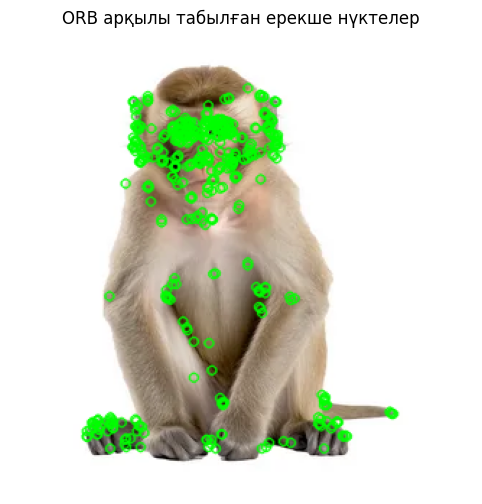

In [ ]:
# ORB объектісін құру
orb = cv2.ORB_create()

# Ерекше нүктелерді (Keypoints) және дескрипторларды табу
keypoints, descriptors = orb.detectAndCompute(gray, None)

# Табылған нүктелерді кескінде салу
image_orb = cv2.drawKeypoints(image_rgb, keypoints, None, color=(0, 255, 0), flags=0)

plt.figure(figsize=(8, 6))
plt.imshow(image_orb)
plt.title('ORB арқылы табылған ерекше нүктелер')
plt.axis('off')
plt.show()

**Нәтижені түсіндіру:**

Жасыл шеңберлер — ORB алгоритмі анықтаған ерекше нүктелер (keypoints). Шеңбер өлшемі нүктенің масштабын (scale), ал бағыты нүктенің орнықты бағдарын (orientation) көрсетеді. Текстуралы, контрасты аймақтарда нүктелер тығыз, жалпақ аймақтарда сирек орналасады.


## 4.3 Дақтарды анықтау және сипаттау (Blob Detection)

**Мақсаты:** Кескіндегі тұрақты аймақтарды (дақтарды немесе blobs) табу үшін SimpleBlobDetector құралын қолдану.

Дақ (blob) — айналасындағы фоннан түсі немесе жарықтығы бойынша ерекшеленетін тұйықталған аймақ немесе дақ. Дақтарды анықтау кескін масштабы өзгерген кезде де жоғалмайтын үлкен объектілерді немесе тұрақты аймақтарды табу үшін өте пайдалы. Бұл әдіс көбінесе медициналық суреттерді талдауда немесе бөлшектерді санауда қолданылады.

### Теориялық негіз

**SimpleBlobDetector алгоритмінің жұмыс принципі:**

```
1. Бинаризация — кескінді minThreshold-тан maxThreshold-қа дейін
   бірнеше табалдырықпен бинарлы кескіндерге түрлендіру
2. Connected Components — байланысқан аймақтарды табу
3. Орталықты есептеу — анықталған аймақтардың центроидтарын табу
4. Біріктіру — minDistBetweenBlobs шарты бойынша жинақтау
5. Сүзгілеу — area, circularity, convexity, inertia бойынша
```

### SimpleBlobDetector_Params баптау параметрлері

| Параметр тобы | Параметрлер | Сипаттамасы |
|---|---|---|
| Ауданы | `filterByArea`, `minArea`, `maxArea` | Дақ ауданын шектеу (пикс²) |
| Дөңгелектігі | `filterByCircularity`, `minCircularity` | 1.0 = тамаша шеңбер, 0 = кез келген |
| Дөңестігі | `filterByConvexity`, `minConvexity` | Дақтың дөңестік деңгейі |
| Инерция | `filterByInertia`, `minInertiaRatio` | Сопақша пішіндерді ажырату |
| Жарықтық | `filterByColor`, `blobColor` | 0 = қара дақтар, 255 = ақ дақтар |
| Жалпы | `minThreshold`, `maxThreshold`, `thresholdStep` | Бинаризация аралығы |

**Кеңейтілген баптау мысалы:**

```python
params = cv2.SimpleBlobDetector_Params()

# Ауданы бойынша
params.filterByArea = True
params.minArea = 200
params.maxArea = 5000

# Дөңгелектігі бойынша (0.7 — дөңгелекке жақын)
params.filterByCircularity = True
params.minCircularity = 0.7

# Дөңестігі бойынша
params.filterByConvexity = True
params.minConvexity = 0.8

detector = cv2.SimpleBlobDetector_create(params)
```

### Дақ анықтаудың балама тәсілдері

| Тәсіл | Функция | Қолданылуы |
|---|---|---|
| SimpleBlobDetector | `cv2.SimpleBlobDetector_create()` | Жалпы мақсат |
| LoG (Laplacian of Gaussian) | `skimage.feature.blob_log()` | Дақ радиусын дәл табу |
| DoG (Difference of Gaussians) | `skimage.feature.blob_dog()` | Жылдам LoG баламасы |
| DoH (Determinant of Hessian) | `skimage.feature.blob_doh()` | Үлкен дақтарға тиімді |
| Watershed | `cv2.watershed()` | Жанасатын объектілерді бөлу |


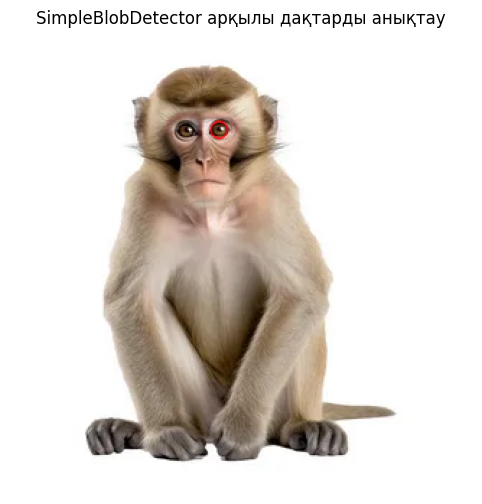

In [ ]:
# Blob детекторының параметрлерін баптау
params = cv2.SimpleBlobDetector_Params()

# Ауданы бойынша фильтрлеуді қосу (тым кішкентай дақтарды елемеу)
params.filterByArea = True
params.minArea = 100

# Детекторды құру
detector = cv2.SimpleBlobDetector_create(params)

# Дақтарды (Keypoints) табу
keypoints_blob = detector.detect(gray)

# Дақтарды қызыл шеңберлермен белгілеу
image_blob = cv2.drawKeypoints(image_rgb, keypoints_blob, np.array([]), (255, 0, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(8, 6))
plt.imshow(image_blob)
plt.title('SimpleBlobDetector арқылы дақтарды анықтау')
plt.axis('off')
plt.show()

**Нәтижені түсіндіру:**

Қызыл шеңберлер  SimpleBlobDetector анықтаған дақтар. Шеңбер өлшемі дақтың ауданына пропорционал. `minArea = 100` шарты кішкентай шу нүктелерін елемеуге мүмкіндік береді.

Дақ анықталмаса немесе тым аз болса — `minArea` мәнін азайтыңыз немесе `filterByColor` параметрін тексеріңіз: фондық және дақ жарықтыққа байланысты `blobColor = 0` немесе `255` таңдаңыз.


# Тапсырмалар

Төмендегі тапсырмаларды орындап, нәтижелерін осы ноутбукке қосыңыз.


### Тапсырма 1 — Собель ядросы

`cv2.Sobel` функциясындағы `ksize=3` өлшемін `5` немесе `7`-ге ауыстырыңыз. Шеттердің қалыңдығы мен анықтығы қалай өзгерді?

```python
sobel_x5 = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_x7 = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=7)
```

---

### Тапсырма 2 — Канни табалдырығы

`cv2.Canny` ішіндегі `100` және `200` мәндерін `30` және `80` етіп азайтып көріңіз. Қандай ұсақ детальдар пайда болды?

```python
canny_soft = cv2.Canny(gray, 30, 80)
canny_hard = cv2.Canny(gray, 150, 300)
```

---

### Тапсырма 3 — Харрис сезімталдығы

`cv2.cornerHarris` ішіндегі `k = 0.04` константасын `0.01` және `0.09` мәндерімен алмастырыңыз. Бұл табылған бұрыштар санына қалай әсер етеді?

```python
dst_sensitive = cv2.cornerHarris(gray_float, 2, 3, 0.01)
dst_strict    = cv2.cornerHarris(gray_float, 2, 3, 0.09)
```

---

### Тапсырма 4 — ORB шектеуі

`cv2.ORB_create(nfeatures=50)` параметрі арқылы алгоритмге тек ең маңызды 50 ерекше нүктені ғана табуды бұйырыңыз.

```python
orb_50 = cv2.ORB_create(nfeatures=50)
kp_50, _ = orb_50.detectAndCompute(gray, None)
```

---

### Тапсырма 5 — Дақтар пішіні

`SimpleBlobDetector_Params` ішінде `filterByCircularity = True` қосып, тек дөңгелек объектілерді анықтап көріңіз.

```python
params.filterByCircularity = True
params.minCircularity = 0.7
```

---

### Тапсырма 6 — Шуға төзімділік

Осы алгоритмдерді сапасы төмен, шулы суретке қолданып, қай әдіс тұрақты нәтиже көрсететінін салыстырыңыз.

```python
# Гаусс шуы қосу
noise = np.random.normal(0, 25, gray.shape).astype(np.int16)
noisy = np.clip(gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)
```



---

# Қорытынды

Осы ноутбукта шеттерді, бұрыштарды және дақтарды анықтаудың негізгі алгоритмдері қарастырылды.

| Тақырып | Меңгерілген функциялар |
|---|---|
| Шет анықтау (1-туынды) | `cv2.Sobel`, `cv2.Scharr`, `cv2.filter2D` |
| Шет анықтау (2-туынды) | `cv2.Laplacian`, `cv2.Canny` |
| Бұрыш анықтау | `cv2.cornerHarris`, `cv2.goodFeaturesToTrack` |
| Ерекше нүктелер | `cv2.ORB_create`, `cv2.FAST`, `cv2.SIFT_create` |
| Дақ анықтау | `cv2.SimpleBlobDetector_create`, `skimage.feature.blob_log` |

### Алгоритмдерді таңдау нұсқаулығы

| Тапсырма | Ұсынылатын алгоритм |
|---|---|
| Жылдам шет анықтау | Sobel немесе Scharr |
| Дәл, жіңішке шеттер | Canny |
| Объектілерді бақылау (tracking) | Shi-Tomasi + оптикалық ағын |
| Кескіндерді сәйкестендіру | ORB немесе SIFT |
| Дөңгелек нысандарды санау | SimpleBlobDetector немесе HoughCircles |

### Пайдалы сілтемелер

- OpenCV Feature Detection: https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html
- Canny Edge Detection теориясы: https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
- Harris Corner теориясы: https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html


## Тапсырма 1 — Собель ядросы

**Бақылау:**
- `ksize = 3` → шеттер жұқа және нақты, бірақ шуға сезімтал.
- `ksize = 5` → шеттер қалыңырақ, бірақ тұрақтырақ.
- `ksize = 7` → шеттер одан да қалың, кейбір ұсақ детальдар жоғалады.

**Қорытынды:** ядро өлшемі үлкейген сайын шеттер жұмсарып, қалыңдайды, бірақ шу әсері азаяды.


## Тапсырма 2 — Канни табалдырығы

**cv2.Canny(gray, 30, 80):**
- Көптеген ұсақ детальдар анықталады
- Шу мен артық шеттер көбейеді

**cv2.Canny(gray, 150, 300):**
- Тек ең айқын шеттер қалады
- Нәтиже таза

**Қорытынды:** табалдырық төмен болса – көбірек шеттер анықталады, бірақ шу көбейеді.


## Тапсырма 3 — Харрис параметрі

`k` параметрі бұрыш анықтау сезімталдығын реттейді.

- `k = 0.01` → өте сезімтал, көп бұрыш табады.
- `k = 0.04` → баланс (классикалық мән).
- `k = 0.09` → тек ең анық бұрыштар ғана қалады.

**Қорытынды:** `k` артқан сайын табылған бұрыштар саны азаяды.


## Тапсырма 4 — ORB

`cv2.ORB_create(nfeatures=50)` параметрі алгоритмге тек 50 ең маңызды keypoint табуға мүмкіндік береді.

**Артықшылықтары:**
- Есептеу жылдамырақ
- Ең маңызды нүктелер ғана таңдалады


## Тапсырма 5 — Blob Detector

`filterByCircularity = True` және `minCircularity = 0.7`

Бұл параметрлер алгоритмге тек дөңгелек пішінге жақын объектілерді анықтауға мүмкіндік береді.

Ұзын немесе бұрышты объектілер ескерілмейді.


## Тапсырма 6 — Шу

| Алгоритм | Шу әсері |
|---|---|
| Sobel | Орташа |
| Laplacian | Шу күшейеді |
| Canny | Ең тұрақты |
| Harris | Орташа |
| ORB | Жақсы |
| Blob Detector | Параметрге тәуелді |

**Қорытынды:** Canny ең тұрақты, себебі ол Gaussian blur арқылы шуды азайтады.
